In [1]:
import os                    
import matplotlib           
import matplotlib.pyplot as plt
import numpy as np            
import astropy.io.fits       
import astropy.coordinates   
import fitsio               
import sdss_access          
from astropy.coordinates import SkyCoord
import astropy.units as u

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')

sdss_path = sdss_access.path.Path(release='dr19', verbose=True)

In [2]:
# from lab04
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('', full=allspec_file):
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()

allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

In [3]:
# Just to see
print(allspec.dtype.names)

('allspec_id', 'multiplex_id', 'sdss_phase', 'observatory', 'instrument', 'sdss_id', 'catalogid', 'fiberid', 'ifudsgn', 'plate', 'fps_field', 'plate_or_fps_field', 'mjd', 'run2d', 'run1d', 'coadd', 'apred_vers', 'drpver', 'version', 'programname', 'survey', 'sas_file', 'cas_url', 'sas_url', 'ra', 'dec', 'healpix', 'healpixgrp', 'apogee_id', 'apogee_field', 'telescope', 'file_spec', 'apstar_id', 'visit_id', 'mangaid', 'specobjid')


In [5]:
# From lab 04
center_ra = [153.]
center_dec = [10.]
center_coords = astropy.coordinates.SkyCoord(center_ra, center_dec, unit='deg', frame='icrs')

unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
sep = sep.value   # get separation from each object and target location in units of degrees


In [6]:
# troubleshoot
print(len(unique_ra), len(unique_dec))
print(np.sum(np.isfinite(unique_ra)), np.sum(np.isfinite(unique_dec)))
print(unique_ra[:10], unique_dec[:10])


3565968 3565968
3565968 3565968
[323.38295    210.24514     41.72804776 315.78003879 313.03884491
 313.34928663 313.87665528 312.46765262 315.58225973 309.01657814] [10.683587   16.007799    0.23160161 -3.21313272 -4.85150701 -4.89841168
 -5.11600638 -5.66162438 -7.59098463 -6.07528056]


In [7]:
# Lab04 code mod

# Fries's quasar coordinates
ra_fries = 212.67189
dec_fries = 53.313609

target = SkyCoord(ra_fries*u.deg, dec_fries*u.deg) # target location

# Extract unique objects from allspec (all lowercase here)
unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

mask = np.isfinite(unique_ra) & np.isfinite(unique_dec) #np.isfinite from APPM2360 project 2
# np.isfinite https://medium.com/@whyamit404/understanding-numpy-isfinite-with-examples-7305ff609ce9 

# update unique_ra and unique_dec with only usable numbers
unique_ra = unique_ra[mask]
unique_dec = unique_dec[mask]
unique_sdss_id = unique_sdss_id[mask]

# indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords) except I don't wnat to center them I want the exact target to match my unique_coord 
unique_coords = SkyCoord(unique_ra, unique_dec, unit='deg') # this is where units='deg' comes in
indx, sep, _ = target.match_to_catalog_sky(unique_coords) # I use "_" becasue the variable is temporary and mostly a placeholder
#Find an ID for this quasar so I don't have to rmember Ra/Dec
fries_sdss_id = unique_sdss_id[indx] # Maybe we can use this in Sky server?
print("Fries's SDSS-V ID:", fries_sdss_id)
print("Angular separation (arcsec):", sep.to(u.arcsec).value)


Fries's SDSS-V ID: 62243506
Angular separation (arcsec): [0.23233907]


In [8]:
#Kelly's code
# New coordinates to test
target_ra_4 = 36.730377  
target_dec_4 = 1.117010
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")
    
    
  

Target: RA 36.730377, Dec 1.11701
Number of Epochs found: 19
Verdict: Still in the low-count zone. The search continues!


In [9]:
#Kelly's code
# New coordinates to test
target_ra_4 = 333.893768       
target_dec_4 = 0.356651       
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")
    
    
  

Target: RA 333.893768, Dec 0.356651
Number of Epochs found: 25
Verdict: This is a high-density target! Worth investigating.


In [10]:
#Kelly's code
# New coordinates to test
target_ra_4 = 333.893768       
target_dec_4 = 0.356651       
tolerance = 0.0005

# Search the master index
mask_4 = (np.abs(allspec['ra'] - target_ra_4) < tolerance) & \
         (np.abs(allspec['dec'] - target_dec_4) < tolerance)

epoch_count_4 = np.sum(mask_4)

print(f"Target: RA {target_ra_4}, Dec {target_dec_4}")
print(f"Number of Epochs found: {epoch_count_4}")

if epoch_count_4 > 20:
    print("Verdict: This is a high-density target! Worth investigating.")
else:
    print("Verdict: Still in the low-count zone. The search continues!")


Target: RA 333.893768, Dec 0.356651
Number of Epochs found: 25
Verdict: This is a high-density target! Worth investigating.


In [11]:
# check how mny visits this quasar has (hopefully a lot)
fries_rows = allspec[allspec['sdss_id'] == fries_sdss_id]
# If I print the length of rows for this quasar it should tell me how many times it is in the d19 allspec dataset which is really the number of epochs it has.
print("Number of epochs:", len(fries_rows))

Number of epochs: 280


In [12]:
# Now that we know there are multiple visits we can pull the data from those visits to start analyzing the spectra
spectra = []

for row in fries_rows:
    # I was getting an error something about bytes not str???
    sas_url = row['sas_url'].decode()
    local_path = sas_url.replace(url_root, local_root)

    # From lab04 and others 
    if not os.path.exists(local_path):
        access.remote()
        access.add(row['sas_url']) #line of error?
        access.set_stream()
        access.commit()

    # open the FITS file
    hdul = astropy.io.fits.open(local_path)
    data = hdul[1].data

    wavelength = 10**data['loglam']
    flux = data['flux']
    mjd = row['mjd']

    spectra.append({
        "wavelength": wavelength,
        "flux": flux,
        "mjd": mjd
    })
### Needs to be fixed

In [13]:
# Allspec does not have z specs so I should load in spall
# Load spAll Like in lab04 and others
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('', full=spall_file):
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()

print("spAll file:", spall_file)

# Not alspec anymore -> spall uses all CAPS!
spall_columns = [
    'SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS',
    'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG', 'SPEC_FILE',
    'HEALPIX_PATH', 'OBJTYPE'
]

spall = fitsio.read(spall_file, columns=spall_columns)

spAll file: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


In [27]:
from __future__ import print_function
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

## Load any FITs file ##
path='' # If error check %pwd
file_name = path+'spec-7339-56799-0611.fits'
f = fits.open(file_name)

In [28]:
# let's measure some properties of the continuum spectrum
# the continuum is the flattish part not including discrete atomic transitions
wavelength = 10**f[1].data['loglam']
flux = f[1].data['flux']

In [29]:
# hopefully I can find Fries's quasar in spall. I will also need to get Z from spall
fries_spall_rows = spall[spall['SDSS_ID'] == fries_sdss_id]
print(fries_spall_rows['Z'])

[0.3618605  0.36197636 0.3617574  0.3620082  0.36171433 0.36175856
 0.36173508 0.36170194 0.36175203 0.3621138  0.3619729  0.36186185
 0.36186624 0.36183053 0.36179656 0.3617485  0.36179873 0.36188015
 0.36211374 0.3618566  0.36218318 0.36214086 0.36199072 0.3621246
 0.36208212 0.36195245 0.36194625 0.36208022 0.36207116 0.3620692
 0.36185    0.36214396 0.36211532 0.36206537 0.3620477  0.6701438
 0.36195973 0.36213586 0.3621647  0.36201563 0.36204848 0.3618897
 0.3618902  0.3618361  0.362116   0.36192483 0.3619615  0.3619282
 0.3618892  0.36209273 0.36192626 0.36196038 0.3619643  0.3623556
 0.36242092 0.3620125  0.3625006  0.3621733  0.36256585 0.36251634
 0.36250922 0.3620076  0.3620246  0.3618212  0.36205733 0.36185077
 0.36175546 0.36176348 0.36158508 0.3615575  0.36175618 0.36156446
 0.36190262 0.36165494 0.36166543 0.36154643 0.36167973 0.3614836
 0.36162034 0.36241087 0.36236888 0.36232847 0.3623397  0.3626692
 0.36240867 0.36256713 0.36254978 0.36253163 0.3621885  0.36223876
 0.

In [30]:


## useful atomic emission lines in quasar spectra (units of Angstrom, same as our spectra): ##
    # (from day 1 nb)
rest_lambda = {
    "OVI":     1034.0,
    "Lyalpha": 1216.0,
    "CIV":     1549.0,
    "CIII":    1908.0,
    "MGII":    2799.0,
    "Hbeta":   4862.0,
    "Hgamma":  4361.0,
    "Halpha":  6564.0
}

In [32]:
# pipeline redshift
z = f[2].data['Z']
print('pipeline redshift: ',z[0])

pipeline redshift:  0.3595708


In [34]:
# H Beta
lambda_rest_h_beta = rest_lambda["Hbeta"]
#print to check
print(f'The rest wavelength of H Beta is: {lambda_rest_h_beta} Angstroms.') 

# H alpha
lambda_rest_h_alpha = rest_lambda["Halpha"]
#print to check
print(f'The rest wavelength of H alpha is: {lambda_rest_h_alpha} Angstroms.') 

The rest wavelength of H Beta is: 4862.0 Angstroms.
The rest wavelength of H alpha is: 6564.0 Angstroms.


In [37]:
# Calculate the observed wavelength
lambda_obs_h_beta = (1+z[0]) * lambda_rest_h_beta #z[0] makes result scalar
print(f'The observed wavelength of H beta is: {lambda_obs_h_beta:.4f} Angstroms.')

# Calculate the observed wavelength
lambda_obs_h_alpha = (1+z[0]) * lambda_rest_h_alpha #z[0] makes result scalar
print(f'The observed wavelength of H alpha is: {lambda_obs_h_alpha:.4f} Angstroms.')

The observed wavelength of H beta is: 6610.2332 Angstroms.
The observed wavelength of H alpha is: 8924.2227 Angstroms.


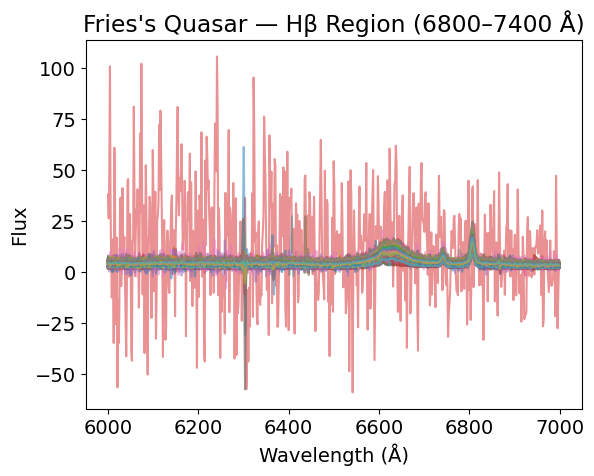

In [42]:
### H Beta region
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6000) & (wl < 7000)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hβ Region (6800–7400 Å)")
plt.show();

# These are the BLR plots 

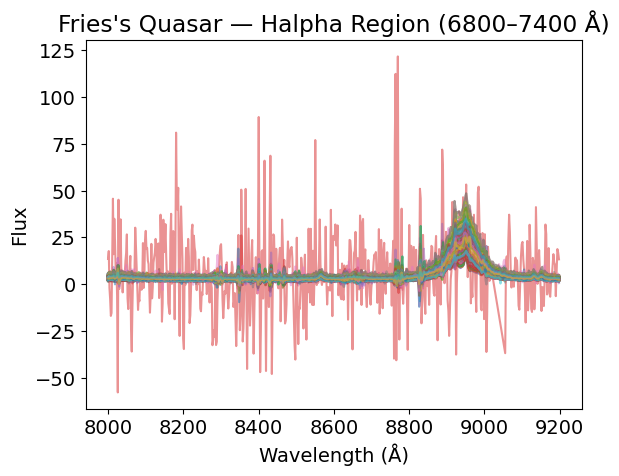

In [41]:
#### H Alpha region
matplotlib.rcParams['text.usetex'] = False # I remember needing something liek this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 8000) & (wl < 9200)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Halpha Region (6800–7400 Å)")
plt.show();

# These are the BLR plots 

[WARNING]: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument. (UserWarning)


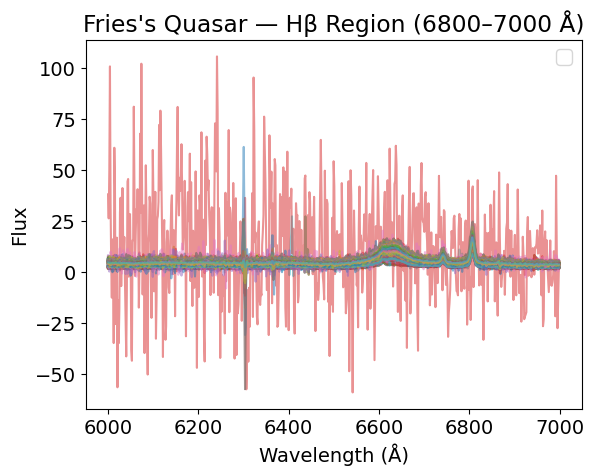

In [46]:
#### H beta

matplotlib.rcParams['text.usetex'] = False # I remember needing something like this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6000) & (wl < 7000)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — Hβ Region (6800–7000 Å)")
plt.legend()
plt.show();

# These are the BLR plots 

Next steps: Random code ideas for plots

[WARNING]: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument. (UserWarning)


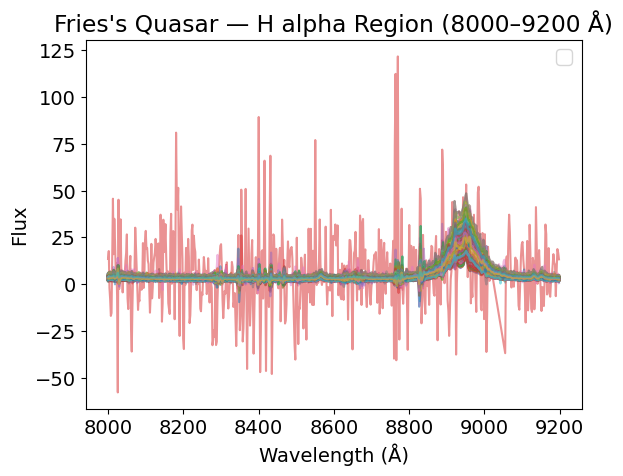

In [47]:
#### H alpha

matplotlib.rcParams['text.usetex'] = False # I remember needing something like this. It will error otherwise
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 8000) & (wl < 9200)
    plt.plot(wl[mask], fl[mask], alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Fries's Quasar — H alpha Region (8000–9200 Å)")
plt.legend()
plt.show();

# These are the BLR plots 

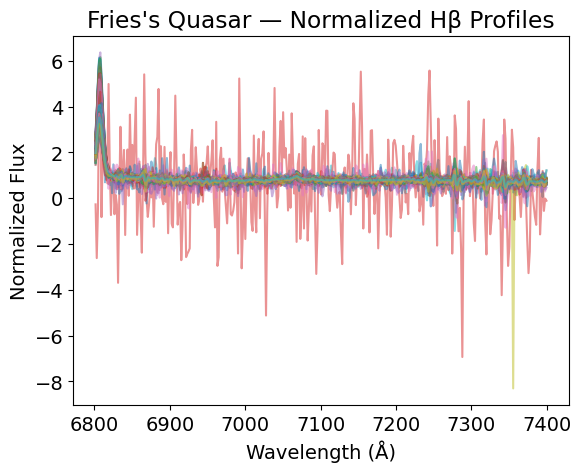

In [18]:
for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]

    mask = (wl > 6800) & (wl < 7400)
    wl_zoom = wl[mask]
    fl_zoom = fl[mask]

    # continuum = median of left edge
    cont = np.nanmedian(fl_zoom[(wl_zoom > 6800) & (wl_zoom < 6850)])
    plt.plot(wl_zoom, fl_zoom/cont, alpha=0.5)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Fries's Quasar — Normalized Hβ Profiles")
plt.show();


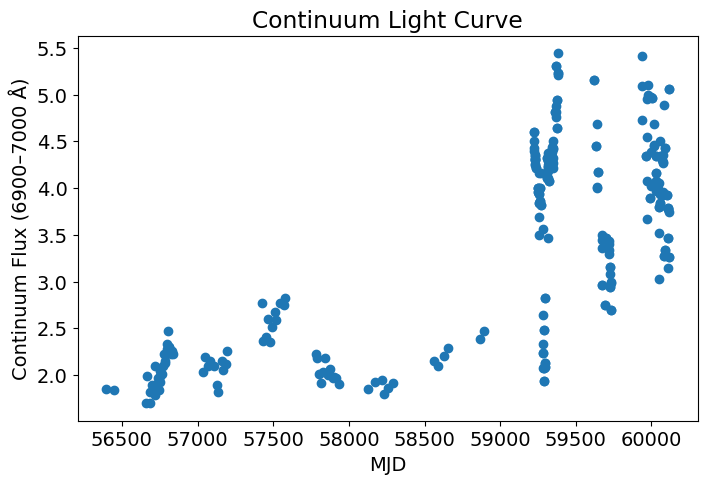

In [19]:
def continuum_flux(wl, fl, lam_min, lam_max):
    mask = (wl > lam_min) & (wl < lam_max)
    return np.nanmedian(fl[mask])

cont_times = []
cont_values = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = continuum_flux(wl, fl, 6900, 7000)  # clean continuum values?
    cont_times.append(mjd)
    cont_values.append(f)

plt.figure(figsize=(8,5))
plt.scatter(cont_times, cont_values)
plt.xlabel("MJD")
plt.ylabel("Continuum Flux (6900–7000 Å)")
plt.title("Continuum Light Curve")
plt.show()


In [ ]:
def line_flux(wl, fl, center, width=40):
    lam_min = center - width
    lam_max = center + width

    mask = (wl > lam_min) & (wl < lam_max)

    # continuum from edges
    cont_mask = ((wl > lam_min) & (wl < lam_min+10)) | \
                ((wl < lam_max) & (wl > lam_max-10))
    cont = np.nanmedian(fl[cont_mask])

    return np.trapz(fl[mask] - cont, wl[mask])

hb_center = 4861 * (1 + z_jason)

hb_times = []
hb_values = []

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mjd = s["mjd"]

    f = line_flux(wl, fl, hb_center)
    hb_times.append(mjd)
    hb_values.append(f)

plt.figure(figsize=(8,5))
plt.scatter(hb_times, hb_values)
plt.xlabel("MJD")
plt.ylabel("Hβ Line Flux")
plt.title("Hβ Light Curve")
plt.show()


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(cont_values, hb_values)
plt.xlabel("Continuum Flux")
plt.ylabel("Hβ Line Flux")
plt.title("BLR Response to Disk Variability")
plt.show()


In [ ]:
# pick bright and faint epochs
i_bright = np.argmax(cont_values)
i_faint = np.argmin(cont_values)

wl_b = spectra[i_bright]["wavelength"]
fl_b = spectra[i_bright]["flux"]

wl_f = spectra[i_faint]["wavelength"]
fl_f = spectra[i_faint]["flux"]

# interpolate faint spectrum onto bright wavelength grid
fl_f_interp = np.interp(wl_b, wl_f, fl_f)

# zoom region
mask = (wl_b > 6800) & (wl_b < 7400)

plt.figure(figsize=(10,6))
plt.plot(wl_b[mask], fl_b[mask] - fl_f_interp[mask])
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux Difference")
plt.title("Difference Spectrum (Bright - Faint)")
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

mjds = np.array([s["mjd"] for s in spectra])
norm = plt.Normalize(mjds.min(), mjds.max())
cmap = plt.cm.viridis

for s in spectra:
    wl = s["wavelength"]
    fl = s["flux"]
    mask = (wl > 6800) & (wl < 7400)
    ax.plot(wl[mask], fl[mask], color=cmap(norm(s["mjd"])), alpha=0.6)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="MJD")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux")
ax.set_title("Time‑Colored Hβ Evolution")

plt.show()


Covariance table

In [ ]:
cont_arr = np.array(cont_values)
hb_arr   = np.array(hb_values)


In [ ]:
cov_matrix = np.cov(np.vstack([cont_arr, hb_arr]))
print("Covariance matrix:")
print(cov_matrix)


In [ ]:
labels = ["Continuum", "Hβ line"]

print("Covariance table:")
for i in range(2):
    for j in range(2):
        print(f"Cov({labels[i]}, {labels[j]}) = {cov_matrix[i, j]:.3e}")


In [ ]:
corr_matrix = np.corrcoef(np.vstack([cont_arr, hb_arr]))
print("Correlation matrix:")
print(corr_matrix)


In [ ]:
print("Correlation table:")
for i in range(2):
    for j in range(2):
        print(f"Corr({labels[i]}, {labels[j]}) = {corr_matrix[i, j]:.3f}")


Summary